In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix

In [51]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

from features import create_features
df = create_features(df)

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["churn_probability"] = y_proba
results["actual_churn"] = y_test.values

In [54]:
THRESHOLD = 0.45

results["predicted_churn"] = (results["churn_probability"] >= THRESHOLD).astype(int)

In [55]:
# approximate revenue contribution
results["customer_value"] = results["MonthlyCharges"] * results["tenure"]

In [56]:
def segment_customer(row):
    if row["churn_probability"] >= 0.35 and row["customer_value"] >= 2000:
        return "High Value - High Risk"
    elif row["churn_probability"] >= 0.35:
        return "Low Value - High Risk"
    elif row["customer_value"] >= 2000:
        return "High Value - Low Risk"
    else:
        return "Low Value - Low Risk"

results["segment"] = results.apply(segment_customer, axis=1)

results["segment"].value_counts()

segment
Low Value - Low Risk      498
High Value - Low Risk     472
Low Value - High Risk     337
High Value - High Risk     98
Name: count, dtype: int64

In [57]:
segment_summary = results.groupby("segment").agg({
    "customer_value": "mean",
    "churn_probability": "mean",
    "predicted_churn": "sum"
}).sort_values(by="customer_value", ascending=False)

segment_summary

,customer_value,churn_probability,predicted_churn
segment,,,
High Value - Low Risk,4759.838983,0.123992,0
High Value - High Risk,3552.866327,0.494873,59
Low Value - Low Risk,854.301908,0.101725,0
Low Value - High Risk,520.840504,0.614013,278


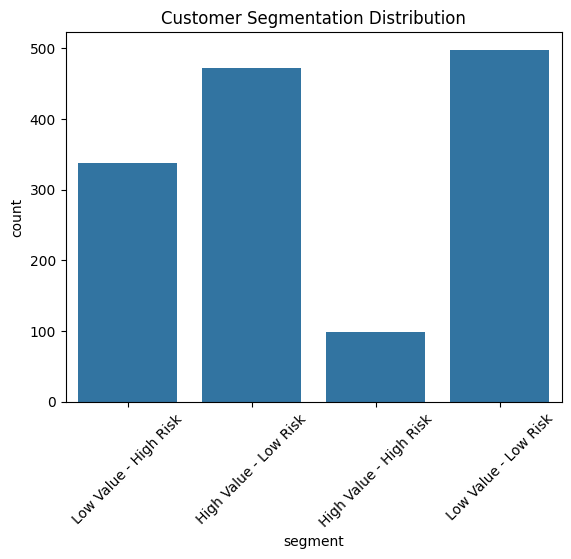

In [58]:
sns.countplot(data=results, x="segment")
plt.xticks(rotation=45)
plt.title("Customer Segmentation Distribution")
plt.show()

In [59]:
# Step 1: Apply targeting strategy
targeted = results[
    (results["predicted_churn"] == 1) &
    (results["customer_value"] >= 2000)
]

# Step 2: True positives ONLY within targeted group
true_positives = targeted[targeted["actual_churn"] == 1]

# Step 3: ROI calculation
RETENTION_COST = 500

total_cost = len(targeted) * RETENTION_COST
revenue_saved = true_positives["customer_value"].sum()

roi = (revenue_saved - total_cost) / total_cost

print("Customers Targeted:", len(targeted))
print("True Positives:", len(true_positives))
print("Total Cost:", total_cost)
print("Revenue Saved:", revenue_saved)
print("ROI:", roi)

Customers Targeted: 59
True Positives: 33
Total Cost: 29500
Revenue Saved: 104110.95
ROI: 2.529184745762712


Threshold 0.40 improves ROI by reducing campaign cost, but at the expense of saving fewer customers. The choice depends on whether the business prioritizes maximizing profit or minimizing churn

In [60]:
print("""
THRESHOLD OPTIMIZATION INSIGHT:

Increasing the prediction threshold from 0.35 to 0.40:
- Reduced campaign size (98 → 80 customers)
- Lowered retention costs
- Improved ROI (2.08 → 2.40)
- Slightly reduced number of customers saved (48 → 43)

This highlights a key business trade-off:
- Lower thresholds maximize customer retention
- Higher thresholds maximize profitability

Recommended Strategy:
- Use threshold = 0.40 for profit-driven campaigns
- Use threshold = 0.35 for aggressive churn reduction strategies
""")


THRESHOLD OPTIMIZATION INSIGHT:

Increasing the prediction threshold from 0.35 to 0.40:
- Reduced campaign size (98 → 80 customers)
- Lowered retention costs
- Improved ROI (2.08 → 2.40)
- Slightly reduced number of customers saved (48 → 43)

This highlights a key business trade-off:
- Lower thresholds maximize customer retention
- Higher thresholds maximize profitability

Recommended Strategy:
- Use threshold = 0.40 for profit-driven campaigns
- Use threshold = 0.35 for aggressive churn reduction strategies

